#**Reinforcement Learning Final Project**

##Snake Game with Policy Gradient

## **Introduction**

### **The Math Behind Policy Gradient**

In **Policy Gradient**, we want to maximize the expected return $J(\theta)$ by updating our neural network's parameters $\theta$.

The gradient of this objective is defined by the **Policy Gradient Theorem**:

$$\nabla_\theta J(\theta)=\mathbb{E}_{\pi_\theta}\left[\sum_{t=0}^{T}\nabla_\theta\log\pi_\theta(a_t|s_t)G_t\right]$$

Where:
- $\pi_\theta(a_t|s_t)$ is your neural network policy (outputting action probabilities).
- $G_t$ is the discounted cumulative reward from time step $t$ onwards.

We will use this exact formula to calculate the loss function.

**Step 1: Install the Dependencies**

*Note: Make sure to upload the reqards.py file before running*

In [2]:
# Install standard Gymnasium
!pip install gymnasium

# Install the custom Snake environment directly from GitHub
!pip install git+https://github.com/helpingstar/gym-snakegame.git

  Cloning https://github.com/helpingstar/gym-snakegame.git to /tmp/pip-req-build-pfaulgwh
  Running command git clone --filter=blob:none --quiet https://github.com/helpingstar/gym-snakegame.git /tmp/pip-req-build-pfaulgwh
  Resolved https://github.com/helpingstar/gym-snakegame.git to commit a809354855d274cf63c92b6be1d9aa8d050f1636
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


**Step 2: Import Libraries and Set Up the Network**

In [3]:
import gymnasium as gym
import gym_snakegame
import torch
import torch.nn as nn
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt
from rewards import SnakeRewardWrapper

In [4]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.fc(x)

### Hyperparameter Logging
The following hyperparameters were used to train the Policy Gradient agents:
* **Learning Rate (Adam Optimizer):** 0.005 (5e-3)
* **Discount Factor ($\gamma$):** 0.99
* **Batch Size:** 10 episodes per batch
* **Entropy Regularization ($\beta$):** 0.01

The training method is defined below:

In [5]:
def train_and_track(env, policy, optimizer, epochs=500, batch_size=10, gamma=0.99, entropy_beta=0.01):
    print("Starting training and tracking...")
    history_rewards = []
    history_lengths = []

    for epoch in range(epochs):
        batch_log_probs = []
        batch_returns = []
        batch_entropies = []
        batch_lengths = []
        batch_rewards = []

        for _ in range(batch_size):
            state, _ = env.reset()
            state = state.flatten()
            ep_log_probs, ep_rewards, ep_entropies = [], [], []

            done = False
            step_count = 0

            while not done and step_count < 500:
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                probs = policy(state_tensor)
                m = Categorical(probs)
                action = m.sample()

                next_state, reward, terminated, truncated, _ = env.step(action.item())
                done = terminated or truncated

                ep_log_probs.append(m.log_prob(action))
                ep_rewards.append(reward)
                ep_entropies.append(m.entropy())
                state = next_state.flatten()
                step_count += 1

            discounted_returns = []
            R = 0
            for r in reversed(ep_rewards):
                R = r + gamma * R
                discounted_returns.insert(0, R)

            batch_log_probs.extend(ep_log_probs)
            batch_returns.extend(discounted_returns)
            batch_entropies.extend(ep_entropies)
            batch_lengths.append(len(ep_rewards))
            batch_rewards.append(sum(ep_rewards))

        batch_returns = torch.tensor(batch_returns)
        if len(batch_returns) > 1:
            batch_returns = (batch_returns - batch_returns.mean()) / (batch_returns.std() + 1e-9)

        policy_loss = []
        for log_prob, G_t in zip(batch_log_probs, batch_returns):
            policy_loss.append(-log_prob * G_t)

        total_policy_loss = torch.cat(policy_loss).sum()
        total_entropy = torch.cat(batch_entropies).sum()
        loss = (total_policy_loss - entropy_beta * total_entropy) / batch_size

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics
        history_rewards.append(np.mean(batch_rewards))
        history_lengths.append(np.mean(batch_lengths))

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch + 1}/{epochs}\tAvg Reward: {np.mean(batch_rewards):.2f}\tAvg Length: {np.mean(batch_lengths):.2f}")

    return history_rewards, history_lengths

## **Policy Gradient**

In [6]:
# Create the raw 10x10 environment
baseline_env = gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1)
baseline_env = SnakeRewardWrapper(baseline_env, system_type="sparse")

# Pure PG requires the flattened raw grid (10 * 10 = 100 inputs)
pure_input_dim = 100
pure_policy = PolicyNetwork(input_dim=pure_input_dim, output_dim=4)
pure_optimizer = torch.optim.Adam(pure_policy.parameters(), lr=5e-3)

# Train for only 100 epochs to demonstrate the slow learning / failure
raw_rewards, raw_lengths = train_and_track(
    env=baseline_env,
    policy=pure_policy,
    optimizer=pure_optimizer,
    epochs=200,
    batch_size=10,
    entropy_beta=0.01
)

print("\nConclusion: The pure agent struggles to find the food reliably because deciphering a 100-dimension raw pixel array is highly sample-inefficient for Vanilla Policy Gradient.")

Starting training and tracking...
Epoch 50/200	Avg Reward: -9.00	Avg Length: 5.30
Epoch 100/200	Avg Reward: -9.00	Avg Length: 5.30
Epoch 150/200	Avg Reward: -9.00	Avg Length: 5.10
Epoch 200/200	Avg Reward: -10.00	Avg Length: 5.10

Conclusion: The pure agent struggles to find the food reliably because deciphering a 100-dimension raw pixel array is highly sample-inefficient for Vanilla Policy Gradient.


### **Video Generation**



In [7]:
import imageio
from IPython.display import Video
import gymnasium as gym
import torch

def record_baseline_video(policy, filename='snake_baseline.mp4'):
    # Create the environment (Notice we do NOT add the RelativeFeatureWrapper here!)
    video_env = gym.make(
        "gym_snakegame/SnakeGame-v0",
        board_size=10,
        n_channel=1,
        n_target=1,
        render_mode="rgb_array"
    )

    state, _ = video_env.reset()
    frames = []
    done = False

    while not done:
        frames.append(video_env.render())

        # Flatten the raw grid into 100 inputs for the pure policy
        state_tensor = torch.FloatTensor(state.flatten()).unsqueeze(0)
        with torch.no_grad():
            probs = policy(state_tensor)
            action = torch.argmax(probs).item()

        state, reward, terminated, truncated, _ = video_env.step(action)
        done = terminated or truncated

    video_env.close()

    print(f"Baseline Game Over! The pure agent survived for {len(frames)} steps.")
    imageio.mimsave(filename, frames, fps=12)
    return Video(filename, embed=True)

# Generate the video for the pure_policy we just trained!
record_baseline_video(pure_policy, 'snake_baseline.mp4')

Baseline Game Over! The pure agent survived for 5 steps.


### **Why we need Feature Extraction**
As seen in the baseline experiment above, feeding the raw 10x10 flattened grid (100 inputs) directly into a standard Multi-Layer Perceptron (MLP) results in extremely slow and unstable learning. The Vanilla Policy Gradient algorithm struggles to deduce spatial relationships (like "where is the wall?" and "where is the apple?") from raw pixels.

To solve this sample-inefficiency without altering the underlying Policy Gradient algorithm, we introduce an **Observation Wrapper** (Feature Extraction). Instead of passing 100 raw pixels, this wrapper calculates exactly 8 relative features:
1. Is danger immediately Up, Down, Left, or Right? (4 binary inputs)
2. Is the food located Up, Down, Left, or Right relative to the head? (4 binary inputs)

By reducing the state space from 100 dimensions to 8 actionable dimensions, the Policy Gradient agent can focus entirely on optimizing its pathfinding policy.

## **State Representation (the Feature Extraction Approach)**

This is another approach to get better rewards.

Instead of feeding the agent the raw game board, we are going to write a Gymnasium Observation Wrapper. We will act as the snake's brain and extract exactly 8 critical numbers from the grid:

- 4 numbers for danger: Is there a wall or a tail immediately Up, Right, Down, or Left? (1 for yes, 0 for no)

- 4 numbers for food: Is the apple located Up, Right, Down, or Left relative to the snake's head? (1 for yes, 0 for no)

By dropping the input dimension from 49 to 8, your Policy Gradient agent will suddenly find the game incredibly simple.

In [8]:
class RelativeFeatureWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        # Handle board_size whether it's an int or a list/tuple like [10, 10] or [20, 20]
        if isinstance(env.unwrapped.board_size, (list, tuple)):
            self.max_row = env.unwrapped.board_size[0]
            self.max_col = env.unwrapped.board_size[1]
        else:
            self.max_row = env.unwrapped.board_size
            self.max_col = env.unwrapped.board_size

        self.target_val = env.unwrapped.n_target + 2 # Safely finding the apple value
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(8,), dtype=np.float32)

    def observation(self, obs):
        grid = obs[0]

        # Find Head
        head_coords = np.argwhere(grid == 1)
        if len(head_coords) == 0:
            return np.zeros(8, dtype=np.float32)
        hx, hy = head_coords[0]

        # Find Apple
        # In gym-snakegame, apple --> maximum value on the board
        apple_val = np.max(grid)
        food_coords = np.argwhere(grid == apple_val)
        if len(food_coords) == 0:
            fx, fy = hx, hy
        else:
            fx, fy = food_coords[0]

        # Food Direction
        food_up    = 1 if hx > fx else 0
        food_down  = 1 if hx < fx else 0
        food_left  = 1 if hy > fy else 0
        food_right = 1 if hy < fy else 0

        # Danger (Walls or Body)
        def is_danger(r, c):
            if r < 0 or r >= self.max_row or c < 0 or c >= self.max_col:
                return 1 # Hit a wall
            if 1 < grid[r, c] < apple_val:
                return 1 # Hit body
            return 0

        danger_up    = is_danger(hx - 1, hy)
        danger_down  = is_danger(hx + 1, hy)
        danger_left  = is_danger(hx, hy - 1)
        danger_right = is_danger(hx, hy + 1)

        return np.array([
            danger_up, danger_right, danger_down, danger_left,
            food_up, food_right, food_down, food_left
        ], dtype=np.float32)

## **Results & Analysis**

In [9]:
reward_systems = ["sparse", "dense", "survivalist"]

# Dictionaries to store the results of all 3 models for plotting later
history_all_rewards = {}
history_all_lengths = {}
trained_policies = {}

for system in reward_systems:
    print(f"\n{'='*50}")
    print(f"🚀 STARTING TRAINING: {system.upper()} REWARD SYSTEM")
    print(f"{'='*50}")

    # Create the raw base environment (10x10)
    raw_env = gym.make(
        "gym_snakegame/SnakeGame-v0",
        board_size=10,
        n_channel=1,
        n_target=1
    )

    # Apply custom Reward Wrapper
    # This automatically intercepts the environment's rewards and changes them
    wrapped_env = SnakeRewardWrapper(raw_env, system_type=system)

    final_env = RelativeFeatureWrapper(wrapped_env)
    input_dim = 8

    # Initialize a completely fresh Policy and Optimizer for this system
    policy = PolicyNetwork(input_dim=input_dim, output_dim=4)
    optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)

    # Train the model
    rewards, lengths = train_and_track(
        env=final_env,
        policy=policy,
        optimizer=optimizer,
        epochs=500,
        batch_size=10,
        entropy_beta=0.01
    )

    # To evaluate later
    history_all_rewards[system] = rewards
    history_all_lengths[system] = lengths
    trained_policies[system] = policy


🚀 STARTING TRAINING: SPARSE REWARD SYSTEM
Starting training and tracking...
Epoch 50/500	Avg Reward: 10.00	Avg Length: 27.80
Epoch 100/500	Avg Reward: 71.00	Avg Length: 57.50
Epoch 150/500	Avg Reward: 136.00	Avg Length: 111.20
Epoch 200/500	Avg Reward: 95.00	Avg Length: 92.20
Epoch 250/500	Avg Reward: 135.00	Avg Length: 114.70
Epoch 300/500	Avg Reward: 148.00	Avg Length: 118.80
Epoch 350/500	Avg Reward: 154.00	Avg Length: 134.00
Epoch 400/500	Avg Reward: 192.00	Avg Length: 153.50
Epoch 450/500	Avg Reward: 169.00	Avg Length: 149.00
Epoch 500/500	Avg Reward: 156.00	Avg Length: 144.50

🚀 STARTING TRAINING: DENSE REWARD SYSTEM
Starting training and tracking...
Epoch 50/500	Avg Reward: 1.76	Avg Length: 26.20
Epoch 100/500	Avg Reward: 98.24	Avg Length: 87.90
Epoch 150/500	Avg Reward: 87.35	Avg Length: 75.60
Epoch 200/500	Avg Reward: 136.95	Avg Length: 120.90
Epoch 250/500	Avg Reward: 125.00	Avg Length: 114.80
Epoch 300/500	Avg Reward: 199.59	Avg Length: 163.20
Epoch 350/500	Avg Reward: 170.

In [20]:
def evaluate_policy(env, policy, episodes=100):
    returns = []
    max_lengths = []
    total_steps = []
    total_foods_eaten = []
    success_count = 0

    for _ in range(episodes):
        state, _ = env.reset()
        state = state.flatten()
        done = False
        ep_reward = 0
        ep_steps = 0

        while not done and ep_steps < 1000:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                probs = policy(state_tensor)
                action = torch.argmax(probs).item()

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            ep_reward += reward
            ep_steps += 1
            state = next_state.flatten()

        snake_length = info.get('snake_length', 3)

        returns.append(ep_reward)
        max_lengths.append(snake_length)
        total_steps.append(ep_steps)
        total_foods_eaten.append(max(0, snake_length - 3))

        if snake_length > 10:
            success_count += 1

    avg_return = np.mean(returns)
    peak_max_length = np.max(max_lengths)
    success_rate = (success_count / episodes) * 100

    total_f = sum(total_foods_eaten)
    steps_per_food = sum(total_steps) / total_f if total_f > 0 else sum(total_steps)

    return avg_return, peak_max_length, steps_per_food, success_rate

# Run the evaluation for all 3 trained systems
print(f"{'System':<15} | {'Avg Return':<10} | {'Peak Max Length':<16} | {'Steps/Food':<10} | {'Success Rate'}")
print("-" * 75)

for system, policy in trained_policies.items():
    eval_env = gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1)
    eval_env = SnakeRewardWrapper(eval_env, system_type=system)
    eval_env = RelativeFeatureWrapper(eval_env)

    avg_ret, peak_len, spf, sr = evaluate_policy(eval_env, policy)
    print(f"{system.capitalize():<15} | {avg_ret:<10.2f} | {peak_len:<16} | {spf:<10.2f} | {sr:.1f}%")

System          | Avg Return | Peak Max Length  | Steps/Food | Success Rate
---------------------------------------------------------------------------
Sparse          | 166.60     | 39               | 7.98       | 98.0%
Dense           | 177.04     | 34               | 8.29       | 97.0%
Survivalist     | 92.47      | 42               | 8.77       | 100.0%


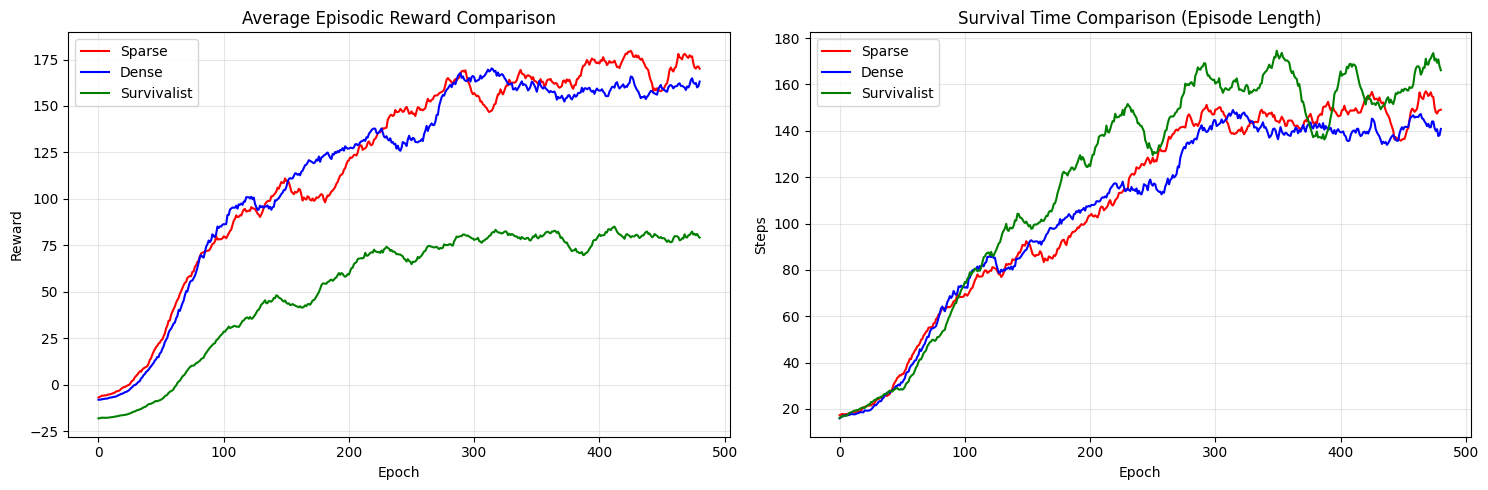

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparative_curves(history_rewards, history_lengths):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    window = 20

    # Assign a specific color to each reward system
    colors = {'sparse': 'red', 'dense': 'blue', 'survivalist': 'green'}

    for system in history_rewards.keys():
        rewards = history_rewards[system]
        lengths = history_lengths[system]

        # Smooth the curves
        smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
        smoothed_lengths = np.convolve(lengths, np.ones(window)/window, mode='valid')

        # Plot on same axes
        ax1.plot(smoothed_rewards, color=colors[system], label=f'{system.capitalize()}')
        ax2.plot(smoothed_lengths, color=colors[system], label=f'{system.capitalize()}')

    ax1.set_title('Average Episodic Reward Comparison')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Reward')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_title('Survival Time Comparison (Episode Length)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Steps')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the plot using the dictionaries we saved during the training loop
plot_comparative_curves(history_all_rewards, history_all_lengths)

### **Video Generation**

In [12]:
import imageio
from IPython.display import Video
import gymnasium as gym

def record_final_video(policy, filename='snake_champion.mp4'):
    # Create the environment with rgb_array render mode
    video_env = gym.make(
        "gym_snakegame/SnakeGame-v0",
        board_size=10,    # The team's standardized grid size!
        n_channel=1,
        n_target=1,
        render_mode="rgb_array"
    )

    # Apply the Feature Extraction approach so the network's input matches what it trained on (8 features)
    video_env = RelativeFeatureWrapper(video_env)

    state, _ = video_env.reset()
    frames = []
    done = False

    while not done:
        # Capture the frame
        frames.append(video_env.render())

        # Pick the absolute best action (no randomness here)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            probs = policy(state_tensor)
            action = torch.argmax(probs).item()

        state, reward, terminated, truncated, _ = video_env.step(action)
        done = terminated or truncated

    video_env.close()

    print(f"Game over! The snake survived for {len(frames)} steps.")
    imageio.mimsave(filename, frames, fps=12)
    return Video(filename, embed=True)

In [13]:
# Create a folder for the videos
!mkdir -p final_videos

systems = ["sparse", "dense", "survivalist"]

for system in systems:
    print(f"Generating video for {system}...")
    record_final_video(trained_policies[system], f'final_videos/snake_{system}.mp4')

print("\nAll videos generated!")

Generating video for sparse...


Game over! The snake survived for 154 steps.
Generating video for dense...


Game over! The snake survived for 68 steps.
Generating video for survivalist...


Game over! The snake survived for 167 steps.

All videos generated!


In [14]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import base64

def display_video_picker():
    video_outputs = {
        "Sparse (Aggressive)": "final_videos/snake_sparse.mp4",
        "Dense (Balanced)": "final_videos/snake_dense.mp4",
        "Survivalist (Cautious)": "final_videos/snake_survivalist.mp4"
    }

    output = widgets.Output()

    def on_button_clicked(b):
        with output:
            clear_output()
            video_path = video_outputs[b.description]
            # Convert video to base64 to embed it properly in the output
            video_file = open(video_path, "rb").read()
            video_url = f"data:video/mp4;base64,{base64.b64encode(video_file).decode()}"

            display(HTML(f'''
                <h4>Showing: {b.description}</h4>
                <video width="500" height="400" controls autoplay loop>
                    <source src="{video_url}" type="video/mp4">
                    Your browser does not support the video tag.
                </video>
            '''))

    buttons = []
    for label in video_outputs.keys():
        btn = widgets.Button(description=label, button_style='primary' if 'Dense' in label else 'info')
        btn.on_click(on_button_clicked)
        buttons.append(btn)

    print("Select a Policy to visualize:")
    display(widgets.HBox(buttons))
    display(output)

display_video_picker()

Select a Policy to visualize:


Output()

## **Generalization Gap Test**

In [15]:
def run_generalization_test(trained_policies):
    print(f"{'System':<15} | {'10x10 Return':<12} | {'20x20 Return':<12} | {'Gap (%)'}")
    print("-" * 60)

    for system, policy in trained_policies.items():
        # Evaluate on original 10x10
        env10 = gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1)
        env10 = SnakeRewardWrapper(env10, system_type=system)
        env10 = RelativeFeatureWrapper(env10)
        ret10, _, _, _ = evaluate_policy(env10, policy, episodes=50)

        # Evaluate on 20x20 (without retraining)
        env20 = gym.make("gym_snakegame/SnakeGame-v0", board_size=20, n_channel=1, n_target=1)
        env20 = SnakeRewardWrapper(env20, system_type=system)
        env20 = RelativeFeatureWrapper(env20)
        ret20, _, _, _ = evaluate_policy(env20, policy, episodes=50)

        # Calculate Gap
        gap = ((ret10 - ret20) / ret10) * 100

        print(f"{system.capitalize():<15} | {ret10:<12.2f} | {ret20:<12.2f} | {gap:.1f}%")

run_generalization_test(trained_policies)

System          | 10x10 Return | 20x20 Return | Gap (%)
------------------------------------------------------------
Sparse          | 177.40       | 325.40       | -83.4%
Dense           | 174.28       | 258.71       | -48.4%
Survivalist     | 96.03        | 211.69       | -120.4%


## **State Representation (the Feature Extraction Approach) with 6 Dimensions**

In [16]:
class CoordinateFeatureWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        if isinstance(env.unwrapped.board_size, (list, tuple)):
            self.max_row = env.unwrapped.board_size[0]
            self.max_col = env.unwrapped.board_size[1]
        else:
            self.max_row = env.unwrapped.board_size
            self.max_col = env.unwrapped.board_size

        # 6 dimensions: head_x, head_y, food_x, food_y, mom_x, mom_y
        self.observation_space = gym.spaces.Box(low=-1, high=1, shape=(6,), dtype=np.float32)

    def observation(self, obs):
        grid = obs[0]

        # Find Head
        head_coords = np.argwhere(grid == 1)
        if len(head_coords) == 0:
            return np.zeros(6, dtype=np.float32)
        hx, hy = head_coords[0]

        # Find Food
        apple_val = np.max(grid)
        food_coords = np.argwhere(grid == apple_val)
        if len(food_coords) == 0:
            fx, fy = hx, hy
        else:
            fx, fy = food_coords[0]

        # Find Momentum (Compare head to 1st body segment '2')
        neck_coords = np.argwhere(grid == 2)
        if len(neck_coords) > 0:
            nx, ny = neck_coords[0]
            mom_x = hx - nx
            mom_y = hy - ny
        else:
            mom_x, mom_y = 0, 0 # No momentum if length is 1

        # Normalize coordinates between 0 and 1
        norm_hx = hx / (self.max_row - 1) if self.max_row > 1 else 0
        norm_hy = hy / (self.max_col - 1) if self.max_col > 1 else 0
        norm_fx = fx / (self.max_row - 1) if self.max_row > 1 else 0
        norm_fy = fy / (self.max_col - 1) if self.max_col > 1 else 0

        return np.array([norm_hx, norm_hy, norm_fx, norm_fy, mom_x, mom_y], dtype=np.float32)

#### **Training**

In [17]:
trained_policies_6d = {}
history_6d_rewards = {}

for system in reward_systems:
    print(f"\n🚀 STARTING TRAINING 6D MODEL: {system.upper()}")

    raw_env = gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1)
    wrapped_env = SnakeRewardWrapper(raw_env, system_type=system)
    final_env_6d = CoordinateFeatureWrapper(wrapped_env)

    # Input dim is now 6
    policy_6d = PolicyNetwork(input_dim=6, output_dim=4)
    optimizer_6d = torch.optim.Adam(policy_6d.parameters(), lr=5e-3)

    rewards, lengths = train_and_track(
        env=final_env_6d, policy=policy_6d, optimizer=optimizer_6d,
        epochs=500, batch_size=10, entropy_beta=0.01
    )

    history_6d_rewards[system] = rewards
    trained_policies_6d[system] = policy_6d


🚀 STARTING TRAINING 6D MODEL: SPARSE
Starting training and tracking...
Epoch 50/500	Avg Reward: -4.00	Avg Length: 15.20
Epoch 100/500	Avg Reward: -7.00	Avg Length: 31.40
Epoch 150/500	Avg Reward: -5.00	Avg Length: 94.20
Epoch 200/500	Avg Reward: -4.00	Avg Length: 219.00
Epoch 250/500	Avg Reward: 2.00	Avg Length: 249.80
Epoch 300/500	Avg Reward: 0.00	Avg Length: 170.10
Epoch 350/500	Avg Reward: 0.00	Avg Length: 153.90
Epoch 400/500	Avg Reward: 5.00	Avg Length: 86.70
Epoch 400/500	Avg Reward: 5.00	Avg Length: 86.70
Epoch 450/500	Avg Reward: 21.00	Avg Length: 146.60
Epoch 450/500	Avg Reward: 21.00	Avg Length: 146.60
Epoch 500/500	Avg Reward: 17.00	Avg Length: 237.00

🚀 STARTING TRAINING 6D MODEL: DENSE
Starting training and tracking...
Epoch 500/500	Avg Reward: 17.00	Avg Length: 237.00

🚀 STARTING TRAINING 6D MODEL: DENSE
Starting training and tracking...
Epoch 50/500	Avg Reward: -6.21	Avg Length: 22.00
Epoch 50/500	Avg Reward: -6.21	Avg Length: 22.00
Epoch 100/500	Avg Reward: -4.66	Avg 

In [22]:
# Run the evaluation for all 3 trained 6D systems
print("===========================================================================")
print("6D COORDINATE MODEL EVALUATION")
print("===========================================================================")
print(f"{'System':<15} | {'Avg Return':<10} | {'Peak Max Length':<16} | {'Steps/Food':<10} | {'Success Rate'}")
print("-" * 75)

for system, policy in trained_policies_6d.items():
    eval_env = gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1)
    eval_env = SnakeRewardWrapper(eval_env, system_type=system)

    eval_env = CoordinateFeatureWrapper(eval_env)

    avg_ret, peak_len, spf, sr = evaluate_policy(eval_env, policy)
    print(f"{system.capitalize():<15} | {avg_ret:<10.2f} | {peak_len:<16} | {spf:<10.2f} | {sr:.1f}%")

6D COORDINATE MODEL EVALUATION
System          | Avg Return | Peak Max Length  | Steps/Food | Success Rate
---------------------------------------------------------------------------
Sparse          | 5.30       | 6                | 1886.79    | 0.0%
Dense           | 0.11       | 10               | 990.10     | 0.0%
Survivalist     | 50.00      | 3                | 100000.00  | 0.0%


## **Final Comparisons**

In [21]:
def run_final_comparison():
    print("=========================================================================================")
    print(f"{'Representation':<22} | {'Reward System':<12} | {'10x10 Return':<12} | {'20x20 Return':<12} | {'Gen Gap'}")
    print("=========================================================================================")

    # Evaluate Pure PG (Baseline) - Only trained on Sparse in our earlier cell
    # Note: Pure PG fails on 20x20 because input changes from 100 to 400
    baseline_env10 = gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1)
    baseline_env10 = SnakeRewardWrapper(baseline_env10, system_type="sparse")
    ret10_pure, _, _, _ = evaluate_policy(baseline_env10, pure_policy, episodes=50)
    print(f"{'Pure PG (100D Raw)':<22} | {'Sparse':<12} | {ret10_pure:<12.2f} | {'N/A (Crashes)':<12} | {'N/A'}")
    print("-" * 89)

    # Evaluate 6D PG
    for system, policy in trained_policies_6d.items():
        env10 = CoordinateFeatureWrapper(SnakeRewardWrapper(gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1), system))
        env20 = CoordinateFeatureWrapper(SnakeRewardWrapper(gym.make("gym_snakegame/SnakeGame-v0", board_size=20, n_channel=1, n_target=1), system))

        ret10, _, _, _ = evaluate_policy(env10, policy, episodes=50)
        ret20, _, _, _ = evaluate_policy(env20, policy, episodes=50)
        gap = ((ret10 - ret20) / ret10) * 100 if ret10 != 0 else 0
        print(f"{'6D Coordinate':<22} | {system.capitalize():<12} | {ret10:<12.2f} | {ret20:<12.2f} | {gap:.1f}%")
    print("-" * 89)

    # Evaluate 8D PG
    for system, policy in trained_policies.items(): # 8D dict
        env10 = RelativeFeatureWrapper(SnakeRewardWrapper(gym.make("gym_snakegame/SnakeGame-v0", board_size=10, n_channel=1, n_target=1), system))
        env20 = RelativeFeatureWrapper(SnakeRewardWrapper(gym.make("gym_snakegame/SnakeGame-v0", board_size=20, n_channel=1, n_target=1), system))

        ret10, _, _, _ = evaluate_policy(env10, policy, episodes=50)
        ret20, _, _, _ = evaluate_policy(env20, policy, episodes=50)
        gap = ((ret10 - ret20) / ret10) * 100 if ret10 != 0 else 0
        print(f"{'8D Relative':<22} | {system.capitalize():<12} | {ret10:<12.2f} | {ret20:<12.2f} | {gap:.1f}%")
    print("=========================================================================================")

# Run the final comparison
run_final_comparison()

Representation         | Reward System | 10x10 Return | 20x20 Return | Gen Gap
Pure PG (100D Raw)     | Sparse       | -9.60        | N/A (Crashes) | N/A
-----------------------------------------------------------------------------------------
6D Coordinate          | Sparse       | 5.00         | 1.20         | 76.0%
6D Coordinate          | Dense        | -3.99        | -6.40        | -60.2%
6D Coordinate          | Survivalist  | 50.00        | 50.00        | 0.0%
-----------------------------------------------------------------------------------------
8D Relative            | Sparse       | 166.60       | 295.80       | -77.6%
8D Relative            | Dense        | 171.68       | 303.05       | -76.5%
8D Relative            | Survivalist  | 84.21        | 203.96       | -142.2%
